# Data set Loading


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import math, itertools, warnings
warnings.filterwarnings('ignore')
np.random.seed()

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(url)
print(df.shape) # expected (1338, 7)
print(df.dtypes)
print(df.head())

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# 1.1 The Normal Distribution - BMI

> ## sample mean (μ) and sample standard deviation (σ)

In [2]:
mean = round(df['bmi'].mean(),4)
std_dev = round(df['bmi'].std(),4)
print("Mean for BMI Column upto 4 Decimal Places is: ",mean)
print("Standard Deviation for BMI Column upto 4 Decimal Places is: ",std_dev)

Mean for BMI Column upto 4 Decimal Places is:  30.6634
Standard Deviation for BMI Column upto 4 Decimal Places is:  6.0982


> ## **Computing CDF**

In [3]:
under_weight_cdf = round(stats.norm.cdf(25,mean,std_dev),4)
temp_cdf = stats.norm.cdf(30,mean,std_dev)
over_weight_cdf = round(temp_cdf - under_weight_cdf,4)
obese_cdf = round(1 - temp_cdf,4)
print("Under Weight Preicted Probabilities are: ",under_weight_cdf)
print("Over Weight Preicted Probabilities are: ",over_weight_cdf)
print("Obese Preicted Probabilities are: ",obese_cdf)

Under Weight Preicted Probabilities are:  0.1765
Over Weight Preicted Probabilities are:  0.2802
Obese Preicted Probabilities are:  0.5433


> ## Actual Proportions

In [4]:
total = len(df)
under_weight_count = len(df[df['bmi'] < 25])
over_weight_count = len(df[(df['bmi'] >= 25) & (df['bmi'] < 30)])
obese_count = len(df[df['bmi'] >= 30])
under_weight_prop = round(under_weight_count / total,4)
over_weight_prop = round(over_weight_count / total,4)
obese_prop = round(obese_count / total,4)

print("Under Weight Proportion: ",under_weight_prop)
print("Over Weight Proportion: ",over_weight_prop)
print("Obese Proportion: ",obese_prop)

results_df = pd.DataFrame({
    'BMI Range': ['Underweight/Normal (<25)', 'Overweight (25-30)', 'Obese (>=30)'],
    'Actual Proportion': [under_weight_prop, over_weight_prop, obese_prop],
    'Predicted (Normal Model)': [under_weight_cdf, over_weight_cdf, obese_cdf]
})
print(results_df)

Under Weight Proportion:  0.1831
Over Weight Proportion:  0.2885
Obese Proportion:  0.5284
                  BMI Range  Actual Proportion  Predicted (Normal Model)
0  Underweight/Normal (<25)             0.1831                    0.1765
1        Overweight (25-30)             0.2885                    0.2802
2              Obese (>=30)             0.5284                    0.5433


> ## Histogram Plot

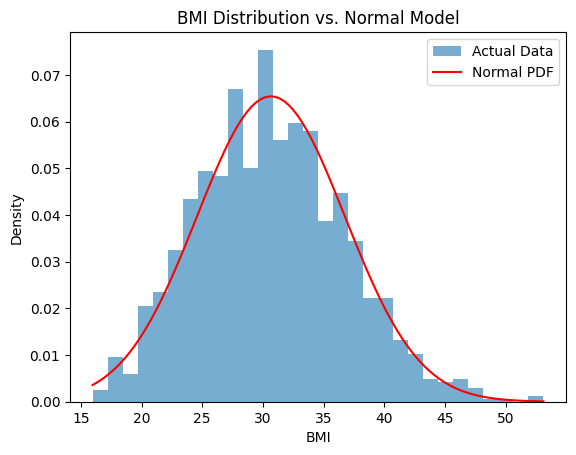

In [5]:
max_bmi = df['bmi'].max()
min_bmi = df['bmi'].min()
points = np.linspace(min_bmi,max_bmi,100)
pdf_value = stats.norm.pdf(points,mean,std_dev)
df['bmi'].plot.hist(bins=30,density=True,label = 'Actual Data',alpha = 0.6)
plt.plot(points,pdf_value,color='red',label = 'Normal PDF')
plt.title("BMI Distribution vs. Normal Model")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

> ## Distribution Analysis of BMI

- **Central Peak:** The actual data shows a slightly higher concentration of policyholders around the BMI range of **30** than the Normal model predicts. This indicates that the average risk group is more tightly clustered than expected.

- **Right-Side Skew:** There is a noticeable **right tail** in the histogram at higher BMI values. Several bars between **BMI 45 and 55** rise above the red PDF line, suggesting that the data is slightly **right-skewed**.

- **Overall Fit:** Despite these minor deviations, the **Normal distribution** remains a strong approximation for the overall BMI distribution of policyholders.

> ## 5th and 95th percentile of BMI

In [6]:
fifth_percentile = round(np.percentile(df['bmi'],5),4)
nintyfifth_percentile = round(np.percentile(df['bmi'],95),4)
fifth_ppf = round(stats.norm.ppf(0.05,mean,std_dev),4)
nintyfifth_ppf = round(stats.norm.ppf(0.95,mean,std_dev),4)
print("5th Percentile of Actual Data: ",fifth_percentile)
print("95th Percentile of Actual Data: ",nintyfifth_percentile)
print("5th Percentile of Modal Data: ",fifth_ppf)
print("95th Percentile of Modal Data: ",nintyfifth_ppf)

5th Percentile of Actual Data:  21.256
95th Percentile of Actual Data:  41.106
5th Percentile of Modal Data:  20.6328
95th Percentile of Modal Data:  40.694


> ## Percentile Comparison and Interpretation

As discussed earlier, the BMI distribution is **right-skewed**, which means the upper end of the data contains more extreme values than a perfectly Normal (model) distribution would predict.

- The **95th percentile** of the actual data is **higher** than the 95th percentile of the model data.
- This indicates that the real dataset contains more individuals with **very high BMI values** than expected under a simple Normal distribution.

Similarly, the **5th percentile** may also differ slightly, but the most noticeable deviation appears in the upper tail due to the right skew.

This confirms that the real-world BMI distribution includes more **“heavier” individuals** than a simple mathematical bell curve can fully account for.

# 1.2 The Binomial Distribution - Smoker Rate

> ## Empirical Probability

In [7]:
smoker_count = len(df[df['smoker'] == 'yes'])
non_smoker_count = len(df[df['smoker'] == 'no'])
smoker_prob = round(smoker_count / total,4)
non_smoker_prob = round(non_smoker_count / total,4)
print("Smoker Empirical Probability is: ",smoker_prob)
print("Non-Smoker Empirical Probability is: ",non_smoker_prob)

Smoker Empirical Probability is:  0.2048
Non-Smoker Empirical Probability is:  0.7952


> ## Probability of Exactly K Smokers 

In [8]:
def binomial_pmf(n, k, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))
n = 50
k = [5,10,15,20]
p = smoker_prob
for i in range(4):
    result = binomial_pmf(n,k[i],p)
    print (f"Binomial Distribuition for k={k[i]} is=",round(result,4))


Binomial Distribuition for k=5 is= 0.0254
Binomial Distribuition for k=10 is= 0.1393
Binomial Distribuition for k=15 is= 0.0346
Binomial Distribuition for k=20 is= 0.0008


> ## **Compute P Using scipy.stats.binom.cdf**

In [9]:
k1 = 7
k2 = 20
Prob_fewer_than_8 = round(stats.binom.cdf(k1,n,smoker_prob),4) * 100
Prob_Greater_than_20 = round(1- stats.binom.cdf(k2,n,smoker_prob),4) * 100
print(f"Probability less than 8: {Prob_fewer_than_8}%",)
print(f"Probability Greater than 20: {Prob_Greater_than_20}%",)


Probability less than 8: 16.89%
Probability Greater than 20: 0.04%


> ## Risk Probability Interpretation

- **Low-Risk Probability:** There is a **16.89%** chance of having fewer than **8 smokers** in a random group of **50** policyholders. This suggests that nearly **1 in 6 groups** will have a relatively low smoking rate, which is favorable for the company’s overall risk profile.

- **High-Risk Probability:** The probability of having more than **20 smokers** in a group of **50** is extremely small, at only **0.04%**. This indicates that the likelihood of encountering an **over-saturated smoker group** is statistically negligible.

- **Conclusion:** Overall, the company’s risk remains well-centered around the expected average. Extreme cases with unusually high smoker concentration are highly unlikely to occur by chance, keeping the insurer’s exposure relatively stable and predictable.

> ## **Simulate 10,000 groups**

In [18]:
size = 10000
simulate_smokers = np.random.binomial(n,smoker_prob,size)
mean = smoker_prob * n
var = smoker_prob * n * non_smoker_prob
simulated_mean = np.mean(simulate_smokers)
simulated_var = np.var(simulate_smokers)
mean_error = (abs(mean - simulated_mean) / var ) * 100
var_error = (abs(var - simulated_var) / mean) * 100
print("Simulated Random Smokers are: ",simulate_smokers)
print("Theoretical Mean is: ",mean)
print("Theoretical Variance is: ",var)
print("Simulated Mean is: ",simulated_mean)
print("Simulated Variance is: ",simulated_var)
print(f"Mean Error is: {mean_error}%")
print(f"Variance Error is: {var_error}%")

Simulated Random Smokers are:  [14  8  7 ... 12 13  9]
Theoretical Mean is:  10.24
Theoretical Variance is:  8.142848
Simulated Mean is:  10.2344
Simulated Variance is:  8.20685664
Mean Error is: 0.06877200704224594%
Variance Error is: 0.6250843749999908%


> ## **Compute Separate Smoker Rates for Males and Females**

In [36]:
male_df = df[df['sex'] == "male"]
female_df = df[df['sex'] == "female"]
male_total = len(male_df)
female_total = len(female_df)
male_smokers_count = len(male_df[male_df['smoker'] == 'yes'])
female_smokers_count = len(female_df[female_df['smoker'] == 'yes'])
male_smokers_prob = male_smokers_count / male_total
female_smokers_prob = female_smokers_count / female_total
expected_male_smokers = round(n * male_smokers_prob,4)
expected_female_smokers = round(n * female_smokers_prob,4)
prob_female_zero_smokers = stats.binom.pmf(0,n,female_smokers_prob)
prob_male_zero_smokers = stats.binom.pmf(0,n,male_smokers_prob)
final_df = {
    'Sex': ['Male','Female'],
    'Expected Smokers': [expected_male_smokers,expected_female_smokers],
    'P(Zero Smokers)':[round(prob_male_zero_smokers,4),round(prob_female_zero_smokers,4)]
    
}
print("Expected Male Smokers are:",expected_male_smokers)
print("Expected Female Smokers are:" ,expected_female_smokers)
print("Probability of Male Zero Smokers: ",prob_male_zero_smokers)
print("Probability of Female Zero Smokers: ",prob_female_zero_smokers)
print("Final Results are: ",final_df)

Expected Male Smokers are: 11.7604
Expected Female Smokers are: 8.6858
Probability of Male Zero Smokers:  1.5038078848587274e-06
Probability of Female Zero Smokers:  7.185662988293868e-05
Final Results are:  {'Sex': ['Male', 'Female'], 'Expected Smokers': [11.7604, 8.6858], 'P(Zero Smokers)': [np.float64(0.0), np.float64(0.0001)]}



## **1.3  The Poisson Distribution - Number of Dependants**

> ## **Compute the mean (λ) and variance**

In [45]:
child_mean = round(df['children'].mean(),4)
child_var = round(df['children'].var(),4)
dispersion_ratio = round(child_mean / child_var,4)
print("Mean:",child_mean)
print("Variance:",child_var)
print("Dispersion Ratio: ",dispersion_ratio)

Mean: 1.0949
Variance: 1.4532
Dispersion Ratio:  0.7534


## Dispersion Ratio Interpretation

The calculated **dispersion ratio** is **0.7534**, which is reasonably close to **1**. In count-data analysis, a dispersion ratio near **1** indicates that the data follows the assumptions of a **Poisson distribution** fairly well.

This suggests that the Poisson model provides a **good fit** for the smoker count data, as the observed variance is close to the mean. Although the ratio is slightly below 1 (indicating mild under-dispersion), it is still close enough to support the conclusion that the **Poisson distribution is an appropriate model** for this dataset.